# 06 Figures
In this notebook the code for the final figures is saved. 

# Load packages

In [1]:
import numpy as np
import pandas as pd 
import xarray as xr
from pathlib import Path
import os

import matplotlib.pyplot as plt
import matplotlib.colors as clrs
import matplotlib.patches as mpatches 
from matplotlib.colors import TwoSlopeNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeatures

ERROR 1: PROJ: proj_create_from_database: Open of /home/b/b383801/.conda/envs/ESDSRS/share/proj failed


# Set working directories

In [9]:
save_script_to = "/home/b/b383801/"
save_data_to = "/work/bb1445/b383801/"
get_data_from = "/work/bb1152/m300755/inputdata/IFS-FESOM/"
save_figures_to = "/home/b/b383801/Final_Notebooks/New_data/ensemble_mean/Figures/"
save_tables_to = "/home/b/b383801/Final_Notebooks/New_data/ensemble_mean/Tables/"

# Functions

## Plot Köppen-Geiger Map with cities 

In [10]:
def plot_koppen_with_cities(city_ds,
                            koppen_ds,
                            koppen_detail="main",
                            color_cities_by="hemisphere",
                            figsize=(12,7),
                            point_size=40,
                            city_alpha=0.9,
                            koppen_alpha=0.7,
                            show_legend=True,
                            save_path=None,
                            output_name=None):

    koppen_colors_detailed = {
        0: "#FFFFFF", 1: "#960000", 2: "#FF0000", 3: "#FF6E6E", 4: "#FFCCCC",
        5: "#CC8D14", 6: "#CCAA54", 7: "#CC6E14", 8: "#CC9654",
        9: "#007800", 10: "#00AA00", 11: "#00D200", 12: "#96FF00",
        13: "#C8FF00", 14: "#C8C800", 15: "#00FF00", 16: "#78FF00", 17: "#64FF00",
        18: "#FFFFB4", 19: "#B4B400", 20: "#969600", 21: "#7D7D00",
        22: "#00FFFF", 23: "#37C8FF", 24: "#0070C8", 25: "#00468C",
        26: "#646464", 27: "#8C8C8C", 28: "#BEBEBE", 29: "#E1E1E1",
        30: "#6496C8", 31: "#FFFFFF",
    }

    koppen_names = {
        1: "Af", 2: "Am", 3: "Aw", 4: "As",
        5: "BWh", 6: "BWk", 7: "BSh", 8: "BSk",
        9: "Csa", 10: "Csb", 11: "Csc", 12: "Cwa", 13: "Cwb", 14: "Cwc",
        15: "Cfa", 16: "Cfb", 17: "Cfc",
        18: "Dsa", 19: "Dsb", 20: "Dsc", 21: "Dsd",
        22: "Dwa", 23: "Dwb", 24: "Dwc", 25: "Dwd",
        26: "Dfa", 27: "Dfb", 28: "Dfc", 29: "Dfd",
        30: "ET", 31: "EF"
    }

    climate_groups = {
        1: "A", 2: "A", 3: "A", 4: "A",
        5: "B", 6: "B", 7: "B", 8: "B",
        9: "C", 10: "C", 11: "C", 12: "C", 13: "C", 14: "C", 15: "C", 16: "C", 17: "C",
        18: "D", 19: "D", 20: "D", 21: "D", 22: "D", 23: "D", 24: "D", 25: "D",
        26: "D", 27: "D", 28: "D", 29: "D",
        30: "E", 31: "E"
    }

    climate_group_colors = {
        "A": "#D62728",   # Tropical  – red
        "B": "#FF7F0E",   # Arid      – orange
        "C": "#2CA02C",   # Temperate – green
        "D": "#1F77B4",   # Continental – blue
        "E": "#C8C8C8",   # Polar     – grey 
        "Unknown": "#808080"
    }

    print("Processing Köppen-Geiger background...")
    kg_class = koppen_ds["kg_class"].values.copy()

    if koppen_detail == "main":
        kg_class_grouped = np.full_like(kg_class, np.nan, dtype=float)
        for class_num, group in climate_groups.items():
            group_num = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5}[group]
            kg_class_grouped[kg_class == class_num] = group_num
        kg_class = kg_class_grouped

    lons_kg = koppen_ds["lon"].values
    lats_kg = koppen_ds["lat"].values

    print("Reading city data from aggregated dataset...")

    city_coords_df = pd.DataFrame({
        "city": city_ds["city"].values,
        "lat": city_ds["lat"].values,
        "lon": city_ds["lon"].values,
        "climate_group": city_ds["kg_class_main"].values,       
    })
    city_coords_df["hemisphere"] = np.where(city_coords_df["lat"] >= 0, "NH", "SH")

    print(f"Found {len(city_coords_df)} cities")
    print("Climate distribution:")
    print(city_coords_df["climate_group"].value_counts())

    fig = plt.figure(figsize=figsize)
    plt.rcParams["font.family"]="serif"
    ax  = plt.axes(projection=ccrs.PlateCarree())
    ax.set_global()

    if koppen_detail == "main":
        colors_list = ["#FFFFFF", "#D62728", "#FF7F0E", "#2CA02C", "#1F77B4", "#C8C8C8"]
        cmap_kg = clrs.ListedColormap(colors_list)
        bounds = np.arange(7) - 0.5
        norm_kg = clrs.BoundaryNorm(bounds, cmap_kg.N)
    else:
        n_classes = 32
        colors_list = [koppen_colors_detailed.get(i, "#CCCCCC") for i in range(n_classes)]
        cmap_kg = clrs.ListedColormap(colors_list)
        bounds = np.arange(n_classes + 1) - 0.5
        norm_kg = clrs.BoundaryNorm(bounds, cmap_kg.N)

    print(f"Plotting Köppen background ({"main" if koppen_detail == "main" else "detailed"})...")
    extent = [lons_kg.min(), lons_kg.max(), lats_kg.min(), lats_kg.max()]
    step = 10
    ax.imshow(kg_class[::step, ::step],
              extent=extent,
              transform=ccrs.PlateCarree(),
              cmap=cmap_kg, norm=norm_kg,
              alpha=koppen_alpha,
              origin="upper", zorder=1,
              interpolation="nearest")

    ax.add_feature(cfeatures.COASTLINE, linewidth=0.5, edgecolor="black", zorder=3)
    ax.add_feature(cfeatures.BORDERS,   linewidth=0.3, linestyle=":",
                   edgecolor="gray", alpha=0.5, zorder=3)

    gl = ax.gridlines(draw_labels=True, linewidth=0.5,
                      color="black", alpha=0.2, linestyle="--", zorder=2)
    gl.top_labels   = False
    gl.right_labels = False
    gl.ylabel_style = {"size":13}
    gl.xlabel_style = {"size": 13}
    
    print("Plotting cities...")
    scatter_kw = dict(transform=ccrs.PlateCarree(),
                      s=point_size, alpha=city_alpha,
                      edgecolors="black", linewidth=1.0, zorder=5)

    if color_cities_by == "hemisphere":
        for hemi, color, marker in [("NH", "#2E86AB", "o"), ("SH", "#A23B72", "o")]:
            sub = city_coords_df[city_coords_df["hemisphere"] == hemi]
            ax.scatter(sub["lon"], sub["lat"], c=color, marker=marker,
                       label=f"{hemi} cities (n={len(sub)})", **scatter_kw)

    elif color_cities_by == "climate_zone":
        for group, color in climate_group_colors.items():
            sub = city_coords_df[city_coords_df["climate_group"] == group]
            if len(sub) > 0:
                ax.scatter(sub["lon"], sub["lat"], c=color,
                           label=f"{group} climate (n={len(sub)})", **scatter_kw)

    elif color_cities_by == "uniform":
        ax.scatter(city_coords_df["lon"], city_coords_df["lat"], c="red",
                   label=f"Cities (n={len(city_coords_df)})", **scatter_kw)

    if show_legend:
        n_per_group = city_coords_df["climate_group"].value_counts()

        city_legend_elements = [
            mpatches.Patch(facecolor=climate_group_colors.get(g, "#808080"),
                           edgecolor="black",
                           label=f"{name} (n={n_per_group.get(g, 0)})")
            for g, name in [("A", "Tropical"),
                             ("B", "Arid"),
                             ("C", "Temperate"),
                             ("D", "Continental"),
                             ("E", "Polar")]                     
        ]

        ax.legend(handles=city_legend_elements,
                  title="Cities per Köppen-Geiger \nClimate Class",
                  fontsize=13, title_fontsize=14,
                  framealpha=0.95, alignment="left")


    detail_str = "Main Groups" if koppen_detail == "main" else "Detailed Classes"

    plt.tight_layout()

    if save_path is not None and output_name is not None:
        full_path = os.path.join(save_path, output_name)
        plt.savefig(full_path, dpi=300, bbox_inches="tight")
        
    return

## Plot global map of UHII, A(UHII), $\Delta$UHII, A($\Delta$UHII)

In [11]:
def plot_temp_diff_with_cc(ds,
                           koppen_ds=None,
                           variable="T2M_mean_mean_urban_high_summer",
                           figsize=(12,7),
                           title=None,
                           cmap=None,
                           vmax=None,
                           vmin=None,
                           xlabel=None,
                           point_size=40,
                           climate_alpha=0.25,
                           show_climate_legend=True,
                           colorbar_tick_step=0.5,
                           save_path=None,
                           output_name=None):

    if variable not in ds.data_vars:
        available = list(ds.data_vars)
        raise ValueError(f"Variable '{variable}' not found in dataset. "
                         f"Available variables: {available}")

    lats = ds["lat"].values
    lons = ds["lon"].values
    values = ds[variable].values

    q1 = np.nanpercentile(values, 25)
    q3 = np.nanpercentile(values, 75)
    iqr = q3 - q1

    iqr_lower = q1 - 1.5 * iqr
    iqr_upper = q3 + 1.5 * iqr

    clip_min = vmin if vmin is not None else iqr_lower
    clip_max = vmax if vmax is not None else iqr_upper

    outlier_mask = (values < clip_min) | (values > clip_max)
    inliner_mask = ~outlier_mask

    print(f"Data range: {np.nanmin(values):.4f} to {np.nanmax(values):.4f}")
    print(f"Colorbar range (IQR): {clip_min:.4f} to {clip_max:.4f}")
    print(f"Outliers: {outlier_mask.sum()} cities")
    print(f"Number of positive values: {np.sum(values > 0)}")
    print(f"Number of negative values: {np.sum(values < 0)}")
    print(f"Number of zero values: {np.sum(values == 0)}")

    has_negative = clip_min < 0
    has_positive = clip_max > 0

    if cmap is None:
        if has_negative and has_positive:
            cmap = "seismic"
        elif has_positive:
            cmap = "Reds"
        else:
            cmap = "Blues_r"

    if has_negative and has_positive:
        norm = TwoSlopeNorm(vmin=clip_min, vcenter=0, vmax=clip_max)
    else:
        norm = plt.Normalize(vmin=clip_min, vmax=clip_max)

    fig = plt.figure(figsize=figsize)
    plt.rcParams["font.family"] = "serif"
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_global()


    climate_legend_handles = None

    if koppen_ds is not None:
        climate_groups = {
            1: "A", 2: "A", 3: "A", 4: "A",
            5: "B", 6: "B", 7: "B", 8: "B",
            9: "C", 10: "C", 11: "C", 12: "C", 13: "C", 14: "C", 15: "C", 16: "C", 17: "C",
            18: "D", 19: "D", 20: "D", 21: "D", 22: "D", 23: "D", 24: "D", 25: "D",
            26: "D", 27: "D", 28: "D", 29: "D",
            30: "E", 31: "E"
        }
        climate_group_colors = {
            "A": "#D62728",   # Tropical
            "B": "#FF7F0E",   # Arid
            "C": "#2CA02C",   # Temperate
            "D": "#1F77B4",   # Continental
            "E": "#C8C8C8",   # Polar
        }
        group_num = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5}

        print("Processing Köppen-Geiger land background (main groups)...")
        kg_class = koppen_ds["kg_class"].values.copy()
        kg_class_grouped = np.full_like(kg_class, np.nan, dtype=float)
        for class_num, group in climate_groups.items():
            kg_class_grouped[kg_class == class_num] = group_num[group]

        lons_kg = koppen_ds["lon"].values
        lats_kg = koppen_ds["lat"].values
        extent  = [lons_kg.min(), lons_kg.max(), lats_kg.min(), lats_kg.max()]
        step    = 10

        colors_list = ["#D62728", "#FF7F0E", "#2CA02C", "#1F77B4", "#C8C8C8"]  # A,B,C,D,E
        cmap_kg = clrs.ListedColormap(colors_list)
        bounds  = np.arange(1, 7) - 0.5
        norm_kg = clrs.BoundaryNorm(bounds, cmap_kg.N)

        ax.imshow(kg_class_grouped[::step, ::step],
                  extent=extent,
                  transform=ccrs.PlateCarree(),
                  cmap=cmap_kg, norm=norm_kg,
                  alpha=climate_alpha,
                  origin="upper", zorder=0.5,
                  interpolation="nearest")

        if show_climate_legend:
            climate_legend_handles = [
                mpatches.Patch(facecolor=climate_group_colors[g], edgecolor="black",
                               alpha=climate_alpha, label=f"{name}")
                for g, name in [("A", "Tropical"), ("B", "Arid"),
                                 ("C", "Temperate"), ("D", "Continental"),
                                 ("E", "Polar")]
            ]
    else:
        ax.add_feature(cfeatures.LAND, facecolor="#f0ece4", zorder=0)

    ax.add_feature(cfeatures.COASTLINE, linewidth=0.35, edgecolor="#999", zorder=1)
    ax.add_feature(cfeatures.BORDERS, linewidth=0.2, edgecolor="#bbb", zorder=1)
    gl = ax.gridlines(draw_labels=True, linewidth=0.4,
                      color="black", alpha=0.2, linestyle="--", zorder=2)
    gl.top_labels   = False
    gl.right_labels = False
    gl.ylabel_style = {"size": 11}
    gl.xlabel_style = {"size": 11}

    scatter_kwargs = dict(cmap=cmap,
                         transform=ccrs.PlateCarree(),
                         edgecolors="black", linewidths=0.35, zorder=3)

    sc = ax.scatter(lons[inliner_mask], lats[inliner_mask],
                    c=values[inliner_mask],
                    norm=norm,
                    s=point_size,
                    marker="o",
                    **scatter_kwargs)
    if outlier_mask.sum() > 0:
        ax.scatter(lons[outlier_mask], lats[outlier_mask],
                    c=values[outlier_mask],
                    s=point_size,
                    vmin=clip_min,
                    vmax=clip_max,
                    marker="^",
                    **scatter_kwargs,
                    label="Outliers")

    cbar = plt.colorbar(sc, ax=ax, orientation="horizontal",
                        pad=0.06, shrink=0.7, aspect=30, extend="both")

    max_abs = max(abs(clip_min), abs(clip_max))
    max_abs_rounded = np.ceil(max_abs / colorbar_tick_step) * colorbar_tick_step

    candidate_ticks = np.arange(-max_abs_rounded, max_abs_rounded + colorbar_tick_step,
                                 colorbar_tick_step)
    tick_values = candidate_ticks[(candidate_ticks >= clip_min) & (candidate_ticks <= clip_max)]

    if 0 not in tick_values:
        tick_values = np.sort(np.append(tick_values, 0))

    cbar.set_ticks(tick_values)
    cbar.set_ticklabels([f"{v:.2f}" for v in tick_values])
    cbar.ax.tick_params(labelsize=11)

    units = ds[variable].attrs.get("units", "K")
    if xlabel is not None:
        label = f"{xlabel}"
    else:
        label = ds[variable].attrs.get("long_name", variable.replace("_", " ").title())
    cbar.set_label(f"{label} [{units}]", fontsize=12)

    handles, labels = ax.get_legend_handles_labels()
    if climate_legend_handles is not None:
        handles = handles + climate_legend_handles
    if handles:
        ax.legend(handles=handles, fontsize=11, title_fontsize=12,
                  loc="lower center", 
                  framealpha=0.9, ncol=len(handles), borderaxespad=0)

    if title is not None:
        ax.set_title(title, fontsize=14, pad=8)

    plt.tight_layout()

    if save_path is not None and output_name is not None:
        full_path = os.path.join(save_path, output_name)
        plt.savefig(full_path, dpi=300, bbox_inches="tight")

    return

## Plot boxplot of UHII, $\Delta$UHII for all summer vs. p95 heatwave days per climate class

In [6]:
def plot_uhii_boxplot_by_heatwave_and_climate(ds,
                                               variable="UHII_summer",
                                               heatwave_conditions=["all", "p95"],
                                               variable_suffix=None,
                                               groupby="kg_main",
                                               figsize=(15, 10),
                                               show_outlier=True,
                                               print_outliers=False,  
                                               vmin=None,
                                               vmax=None,
                                               title=None,
                                               ylabel=None,
                                               xlabel=None,
                                               save_path=None,
                                               output_name=None):
    def make_var_name(condition):
        if condition == "all":
            base = variable
        else:
            base = f"{variable}_{condition}"
        if variable_suffix is not None:
            return f"{base}_{variable_suffix}"
        return base

    if groupby == "kg_main":
        group_values = ds["kg_class_main"].values
        colors_list  = ["#D62728", "#FF7F0E", "#2CA02C", "#1F77B4", "#C8C8C8"]
        group_labels = sorted(np.unique(group_values))
    
    elif groupby == "location":
        group_values = ds["location"].values
        unique_locs  = sorted(np.unique(group_values))
        cmap = plt.get_cmap("tab10", len(unique_locs))
        colors_list  = [clrs.to_hex(cmap(i)) for i in range(len(unique_locs))]
        group_labels = unique_locs
    else:
        raise ValueError(f"groupby must be 'main' or 'location', got '{groupby}'")

    kg_class_main_dic = {"A": "Tropical",
                        "B": "Arid",
                        "C": "Temperate",
                        "D": "Continental"}

    color_map = {g: colors_list[i % len(colors_list)]
                 for i, g in enumerate(group_labels)}

    records = []
    for condition in heatwave_conditions:
        var_name = make_var_name(condition)
        if var_name not in ds.data_vars:
            print(f"Warning: '{var_name}' not found in dataset, skipping")
            continue
        values = ds[var_name].values
        for i, city in enumerate(ds.city.values):
            records.append({
                "city": city,
                "condition": condition,
                "group": group_values[i],
                "value": float(values[i])
            })

    df = pd.DataFrame(records)
    plt.rcParams["font.family"]="serif"
    fig, ax = plt.subplots(figsize=figsize)    

    n_conditions = len(heatwave_conditions)
    n_groups = len(group_labels)
    total_width  = 0.7
    box_width = total_width / n_groups
    offsets = np.linspace(-total_width /1.8 + box_width / 1.8,
                                total_width / 1.8 - box_width / 1.8,
                                n_groups)

    x_positions = np.arange(n_conditions)

    for g_idx, group in enumerate(group_labels):
        group_df = df[df["group"] == group]
        color = color_map[group]

        boxes_data = []
        positions = []
        for c_idx, condition in enumerate(heatwave_conditions):
            subset = group_df[group_df["condition"] == condition]["value"].dropna()
            if len(subset) > 0:
                boxes_data.append(subset.values)
                positions.append(x_positions[c_idx] + offsets[g_idx])

        if len(boxes_data) == 0:
            continue

        bp = ax.boxplot(boxes_data,
                        positions=positions,
                        widths=box_width * 0.85,
                        patch_artist=True,
                        manage_ticks=False,
                        medianprops=dict(color="black", linewidth=1.5),
                        whiskerprops=dict(linewidth=1.0),
                        capprops=dict(linewidth=1.0),
                        showfliers=show_outlier,
                        flierprops=dict(marker="o", markersize=3,
                                        markeredgecolor=color, alpha=0.5))

        for patch in bp["boxes"]:
            patch.set_facecolor(color)
            patch.set_edgecolor("black")
            patch.set_linewidth(0.8)
            if color == "#FFFFFF":
                patch.set_edgecolor("#555555")

    ax.set_xticks(x_positions)
    condition_labels = {"all": "All Summer Days",
                        "no_hw": "No Heatwave Days",
                        "p95": "p95 Heatwave Days"}
    ax.set_xticklabels([condition_labels.get(c, c) for c in heatwave_conditions],
                       fontsize=26)
    ax.tick_params(axis="y", labelsize=26)

    ax.set_ylabel(ylabel if ylabel is not None else variable.replace("_", " "),
                  fontsize=28)
    ax.set_xlabel(xlabel if xlabel is not None else "Heatwave Condition", fontsize=28)
    if title is not None:
        ax.set_title(title, fontsize=32, pad=12)
    ax.axhline(y=0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.grid(True, axis="y", alpha=0.3)

    legend_handles = [
        mpatches.Patch(facecolor=color_map[g],
                       edgecolor="#555555" if color_map[g] == "#FFFFFF" else "black",
                       label=kg_class_main_dic.get(g, g))  
        for g in group_labels
    ]
    ax.legend(handles=legend_handles,
              title="Köppen-Geiger climate class",           
              fontsize=26, title_fontsize=28, loc="upper center", 
               borderaxespad=0, bbox_to_anchor=(0.5,-0.2),
              ncols=len(group_labels)) #1.01, 1

    if vmin is not None or vmax is not None:         
        ax.set_ylim(vmin, vmax) 

    plt.tight_layout()

    if print_outliers:
        for condition in heatwave_conditions:
            for group in group_labels:
                subset = df[(df["condition"] == condition) & (df["group"] == group)]
                vals   = subset["value"].dropna()

                if len(vals) < 4:   # too few points for meaningful IQR
                    continue

                q1    = np.nanpercentile(vals, 25)
                q3    = np.nanpercentile(vals, 75)
                iqr   = q3 - q1
                lower = q1 - 1.5 * iqr
                upper = q3 + 1.5 * iqr

                out = subset[(subset["value"] < lower) | (subset["value"] > upper)].copy()
                out["direction"] = np.where(out["value"] > upper, "upper", "lower")
                out = out.sort_values("value", ascending=False)

                if not out.empty:
                    print(f"\n{"="*60}")
                    print(f"Condition: {condition}  |  Group: {group}  ({len(out)} outliers)")
                    print(out[["city", "value", "direction"]].to_string(index=False))

    if save_path is not None and output_name is not None:
        full_path = os.path.join(save_path, output_name)
        plt.savefig(full_path, dpi=300, bbox_inches="tight")

    print("SUMMARY STATISTICS")
    for condition in heatwave_conditions:
        print(f"\n {condition_labels.get(condition, condition)}:")
        for group in group_labels:
            subset = df[(df["condition"] == condition) & (df["group"] == group)]
            vals = subset["value"].dropna().values

            if len(vals) == 0:
                print(f"{group}: No data")
                continue

            q1, q3 = np.nanpercentile(vals, [25, 75])

            print(f" {group}: n={len(vals):>6,}    "
                 f"mean={np.mean(vals):>7.3f}    "
                 f"median={np.median(vals):>7.3f}    "
                 f"std={np.std(vals):>7.3f}    "
                 f"range=[{np.min(vals):>7.3f}, {np.max(vals):7.3f}]    "
                 f"IQR=[{q1:>7.3f}, {q3:>8.3f}]")

    return

## Plot boxplot of A(UHII), A($\Delta$UHII) per climate class

In [7]:
def plot_uhii_boxplot_and_climate(ds,
                                   variable="amplification_UHII_summer",
                                   groupby="kg_main",
                                   figsize=(10,5),
                                   show_outlier=True,
                                   print_outliers=False,
                                   vmin=None,
                                   vmax=None,
                                   title=None,
                                   ylabel=None,
                                   xlabel=None,
                                   save_path=None,
                                   output_name=None):

    if variable not in ds.data_vars:
        raise ValueError(f"{variable} b it found. Available variables: {ds.data_vars}")

    if groupby == "kg_main":
        group_values = ds["kg_class_main"].values
        colors_list  = ["#D62728", "#FF7F0E", "#2CA02C", "#1F77B4", "#C8C8C8"]
        xlabel_def = "Köppen-Geiger Main Climate Class"
    elif groupby == "location":
        group_values = ds["location"].values
        unique_locs  = sorted(np.unique(group_values))
        cmap = plt.get_cmap("tab10", len(unique_locs))
        colors_list  = [clrs.to_hex(cmap(i)) for i in range(len(unique_locs))]
        xlabel_def = "Location"
    else:
        raise ValueError(f"groupby must be 'kg_main' or 'location', got '{groupby}'")

    group_labels = sorted(np.unique(group_values))
    color_map = {g: colors_list[i % len(colors_list)]
                for i, g in enumerate(group_labels)}

    df = pd.DataFrame({
            "city": ds["city"].values,
            "group": group_values,
            "value": ds[variable].values.astype(float)
        })

    kg_class_main_dic = {"A": "Tropical",
                        "B": "Arid",
                        "C": "Temperate",
                        "D": "Continental"}
    
    plt.rcParams["font.family"]="serif"
    fig, ax = plt.subplots(figsize=figsize)

    boxes_data = []
    positions = []
    box_colors = []

    for i, group in enumerate(group_labels):
        vals = df[df["group"] == group]["value"].dropna().values
        if len(vals) > 0:
            boxes_data.append(vals)
            positions.append(i)
            box_colors.append(color_map[group])

    bp = ax.boxplot(boxes_data,
                    positions=positions,
                    widths=0.5,
                    patch_artist=True,
                    manage_ticks=False,
                    medianprops=dict(color="black", linewidth=2),
                    whiskerprops=dict(linewidth=1.2),
                    capprops=dict(linewidth=1.2),
                    showfliers=show_outlier,
                    flierprops=dict(marker="o", markersize=4, alpha=0.5,
                                    markeredgecolor="black"))

    for patch, color in zip(bp["boxes"], box_colors):
        patch.set_facecolor(color)
        patch.set_edgecolor("black")
        patch.set_linewidth(0.8)
        if color == "#FFFFFF":
            patch.set_edgecolor("#555555")

    if show_outlier:
        for flier, color in zip(bp["fliers"], box_colors):
            flier.set_markerfacecolor(color)
            flier.set_markeredgecolor("black")

    x_labels = [kg_class_main_dic.get(g, g) for g in group_labels] 
    
    ax.set_xticks(range(len(group_labels)))
    ax.set_xticklabels(x_labels, fontsize=18)
    ax.tick_params(axis="y", labelsize=18)
    ax.set_ylabel(ylabel if ylabel else variable.replace("_", " "), fontsize=20)
    ax.set_xlabel(xlabel if xlabel else xlabel_def, fontsize=20)
    ax.set_title(title if title else variable.replace("_", " ") + " by Climate Class",
                 fontsize=24)

    ax.axhline(y=0, color="black", linestyle="--", linewidth=1, alpha=0.6)
    ax.grid(True, axis="y", alpha=0.3, linestyle="--")
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.2)
    
    if vmin is not None or vmax is not None:         
        ax.set_ylim(vmin, vmax) 

    plt.tight_layout()

    if print_outliers:
        for group in group_labels:
            subset = df[df["group"] == group]["value"].dropna()
            if len(subset) < 4:
                continue
            q1, q3 = np.nanpercentile(subset, [25, 75])
            iqr    = q3 - q1
            lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
            out = df[(df["group"] == group) &
                     ((df["value"] < lower) | (df["value"] > upper))].copy()
            out["direction"] = np.where(out["value"] > upper, "upper", "lower")
            if not out.empty:
                print(f"\n{"="*55}")
                print(f"Group: {group}  ({len(out)} outliers)")
                print(out[["city", "value", "direction"]]
                      .sort_values("value", ascending=False)
                      .to_string(index=False))

    if save_path is not None and output_name is not None:
        plt.savefig(os.path.join(save_path, output_name), dpi=300, bbox_inches="tight")

    print("SUMMARY STATISTICS")
    for group in group_labels:
        subset = df[(df["group"] == group)]
        vals = subset["value"].dropna().values

        if len(vals) == 0:
            print(f"{group}: No data")
            continue

        q1, q3 = np.nanpercentile(vals, [25, 75])

        print(f" {group}: n={len(vals):>6,}    "
             f"mean={np.mean(vals):>7.3f}    "
             f"median={np.median(vals):>7.3f}    "
             f"std={np.std(vals):>7.3f}    "
             f"range=[{np.min(vals):>7.3f}, {np.max(vals):7.3f}]    "
             f"IQR=[{q1:>7.3f}, {q3:>8.3f}]")
    return

# Get data

## Daily data

In [12]:
uhii_hist_urb_all_var = xr.open_dataset(save_data_to + "urban/ensemble_mean/include_city_class/UHII/UHII_per_city_extended/uhii_hist_urb_all_var_pooled15.nc")
uhii_cont_urb_all_var = xr.open_dataset(save_data_to + "urban/ensemble_mean/include_city_class/UHII/UHII_per_city_extended/uhii_cont_urb_all_var_pooled15.nc")
uhii_t2k_urb_all_var = xr.open_dataset(save_data_to + "urban/ensemble_mean/include_city_class/UHII/UHII_per_city_extended/uhii_t2k_urb_all_var_pooled15.nc")

sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found


## Köppen-Geiger climate classes

In [13]:
cc_kogei = xr.open_dataset(save_data_to + "cc_Köppen_Geiger/1991_2020/koppen_geiger_0p00833333.nc")

sh: getfattr: command not found


## Summer metrics

In [14]:
summer_climate_metrics_HIST = xr.open_dataset(save_data_to + "urban/ensemble_mean/include_city_class/Summer_metrics_thermodynamics/absolute_scenario_diff/summer_climate_metrics_HIST.nc")
summer_climate_metrics_CONT = xr.open_dataset(save_data_to + "urban/ensemble_mean/include_city_class/Summer_metrics_thermodynamics/absolute_scenario_diff/summer_climate_metrics_CONT.nc")
summer_climate_metrics_T2K = xr.open_dataset(save_data_to + "urban/ensemble_mean/include_city_class/Summer_metrics_thermodynamics/absolute_scenario_diff/summer_climate_metrics_T2K.nc")
summer_climate_metrics_HIST_CONT_diff = xr.open_dataset(save_data_to + "urban/ensemble_mean/include_city_class/Summer_metrics_thermodynamics/absolute_scenario_diff/summer_climate_metrics_HIST_CONT_diff.nc")
summer_climate_metrics_HIST_T2K_diff = xr.open_dataset(save_data_to + "urban/ensemble_mean/include_city_class/Summer_metrics_thermodynamics/absolute_scenario_diff/summer_climate_metrics_HIST_T2K_diff.nc")

sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found


## Amplification

In [15]:
amplification_HIST = xr.open_dataset(save_data_to + "urban/ensemble_mean/include_city_class/Summer_metrics_thermodynamics/absolute_scenario_diff/amplification_HIST.nc")
amplification_CONT = xr.open_dataset(save_data_to + "urban/ensemble_mean/include_city_class/Summer_metrics_thermodynamics/absolute_scenario_diff/amplification_CONT.nc")
amplification_T2K = xr.open_dataset(save_data_to + "urban/ensemble_mean/include_city_class/Summer_metrics_thermodynamics/absolute_scenario_diff/amplification_T2K.nc")
amplification_HIST_CONT_diff = xr.open_dataset(save_data_to + "urban/ensemble_mean/include_city_class/Summer_metrics_thermodynamics/absolute_scenario_diff/amplification_HIST_CONT_diff.nc")
amplification_T2K_HIST_diff = xr.open_dataset(save_data_to + "urban/ensemble_mean/include_city_class/Summer_metrics_thermodynamics/absolute_scenario_diff/amplification_T2K_HIST_diff.nc")

sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found


# Plot Köppen-Geiger map with cities

Processing Köppen-Geiger background...
Reading city data from aggregated dataset...
Found 210 cities
Climate distribution:
climate_group
C    86
D    51
A    42
B    31
Name: count, dtype: int64
Plotting Köppen background (main)...
Plotting cities...


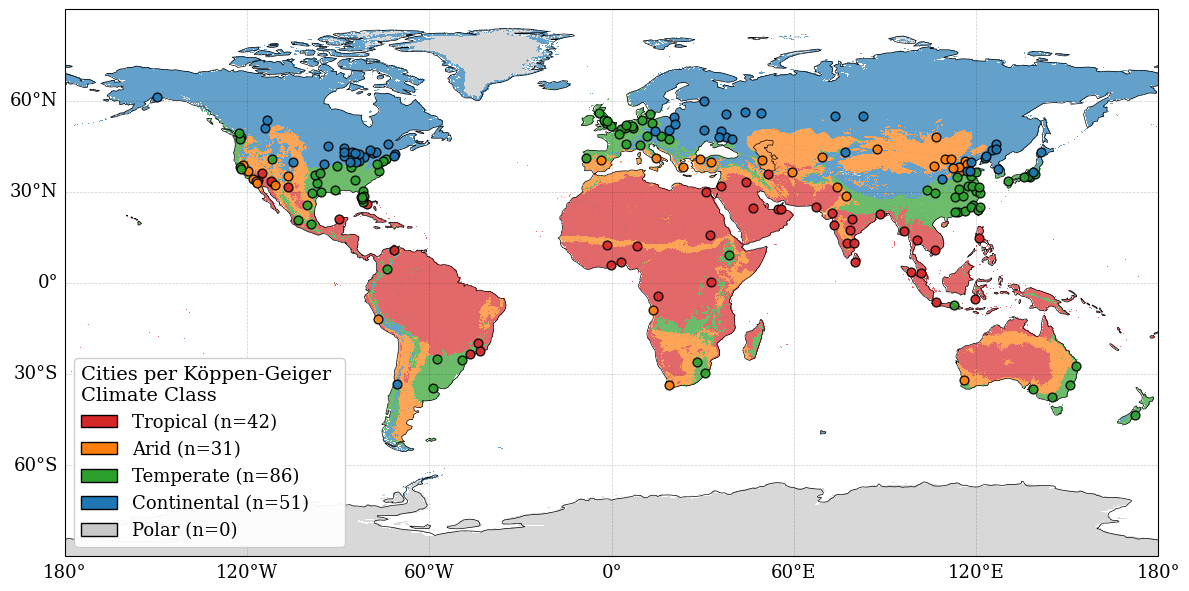

In [14]:
plot_koppen_with_cities(
    city_ds=uhii_hist_urb_all_var,
    koppen_ds=cc_kogei,
    koppen_detail="main",
    color_cities_by="climate_zone",
    point_size=40,
    save_path=save_figures_to,
    output_name="Global_Map_Köppen_Geiger_CC.pdf")

# Plot global map of UHII in HIST 

Data range: -3.8812 to 9.4193
Colorbar range (IQR): -1.2008 to 2.7383
Outliers: 25 cities
Number of positive values: 185
Number of negative values: 25
Number of zero values: 0
Processing Köppen-Geiger land background (main groups)...


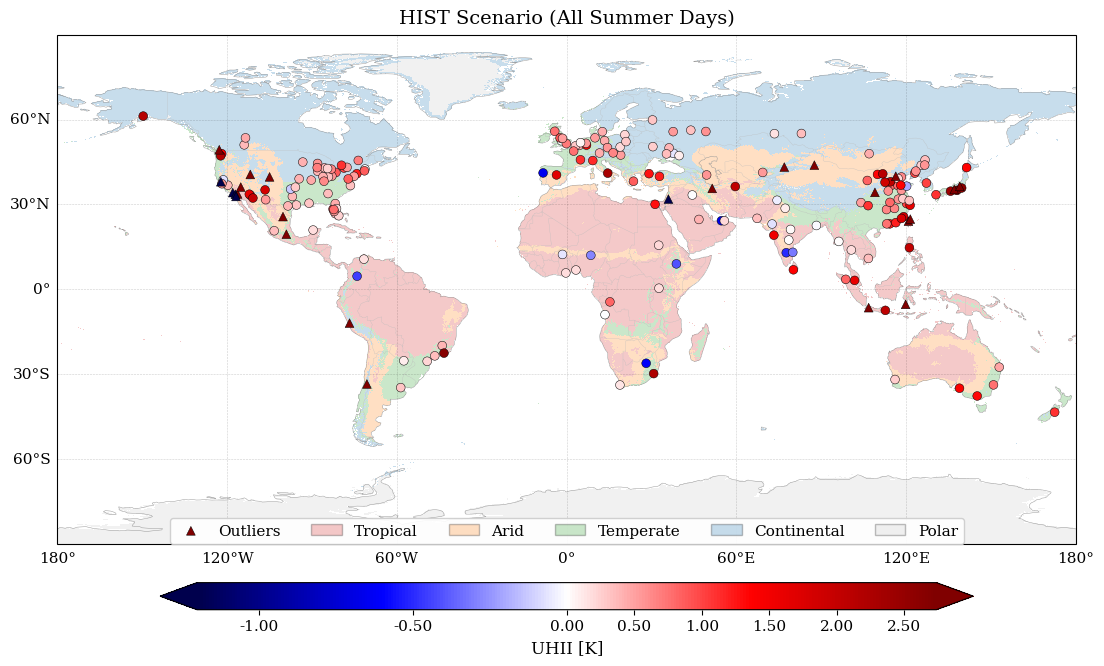

In [16]:
plot_temp_diff_with_cc(summer_climate_metrics_HIST, variable="UHII_summer", koppen_ds=cc_kogei, point_size=40,
                       title="HIST Scenario (All Summer Days)",
                       xlabel="UHII", cmap="seismic", 
                       colorbar_tick_step=0.5,
                       save_path=save_figures_to,
                       output_name="Global_Map_UHII_HIST_all_summer_with_CC.pdf")

Data range: -3.4063 to 10.1739
Colorbar range (IQR): -1.4950 to 3.3882
Outliers: 19 cities
Number of positive values: 190
Number of negative values: 19
Number of zero values: 0
Processing Köppen-Geiger land background (main groups)...


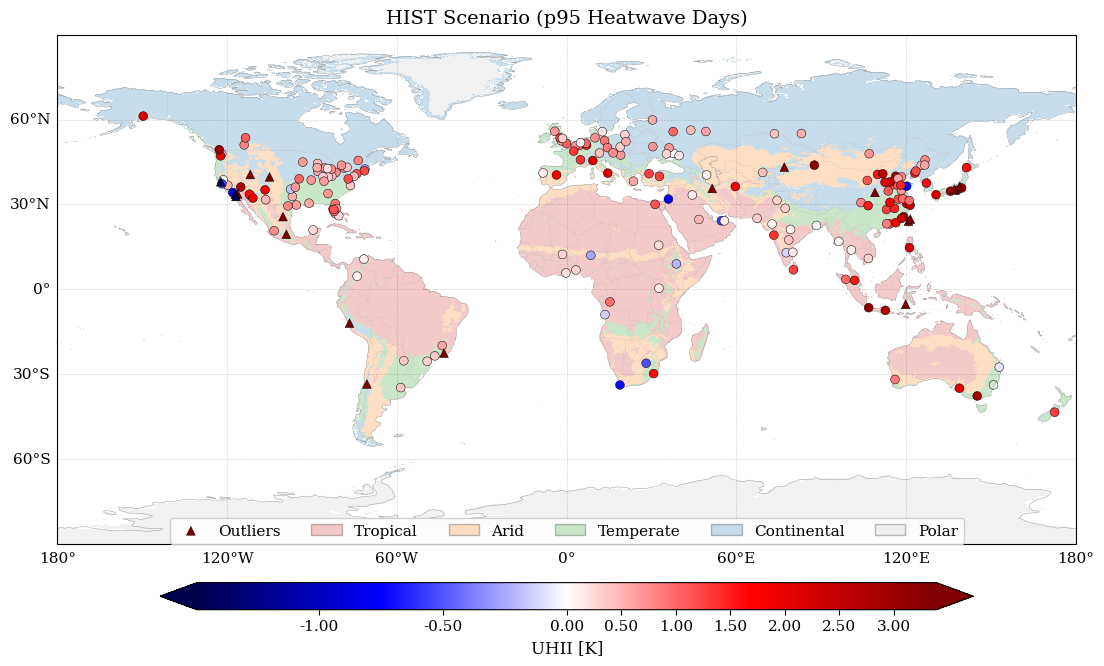

In [17]:
plot_temp_diff_with_cc(summer_climate_metrics_HIST, variable="UHII_summer_p95", koppen_ds=cc_kogei, point_size=40,
                       title="HIST Scenario (p95 Heatwave Days)",
                       xlabel="UHII", cmap="seismic", 
                       save_path=save_figures_to,
                       output_name="Global_Map_UHII_HIST_all_summer_p95_with_CC.pdf")

# Plot boxplot of UHII in HIST for all summer vs. heatwave days

SUMMARY STATISTICS

 All Summer Days:
 A: n=    42    mean=  0.874    median=  0.296    std=  1.543    range=[ -1.435,   6.438]    IQR=[  0.024,    1.359]
 B: n=    31    mean=  0.971    median=  0.852    std=  1.413    range=[ -2.416,   4.939]    IQR=[  0.170,    1.931]
 C: n=    86    mean=  0.929    median=  0.618    std=  1.199    range=[ -3.881,   5.612]    IQR=[  0.353,    1.213]
 D: n=    51    mean=  0.991    median=  0.555    std=  1.531    range=[ -0.058,   9.419]    IQR=[  0.335,    0.883]

 p95 Heatwave Days:
 A: n=    42    mean=  0.970    median=  0.313    std=  1.532    range=[ -0.747,   6.232]    IQR=[  0.125,    1.229]
 B: n=    31    mean=  1.119    median=  1.087    std=  1.705    range=[ -2.794,   7.304]    IQR=[  0.306,    1.917]
 C: n=    85    mean=  1.240    median=  0.949    std=  1.301    range=[ -3.406,   5.846]    IQR=[  0.536,    1.706]
 D: n=    51    mean=  1.212    median=  0.690    std=  1.705    range=[ -0.242,  10.174]    IQR=[  0.456,    1.069]


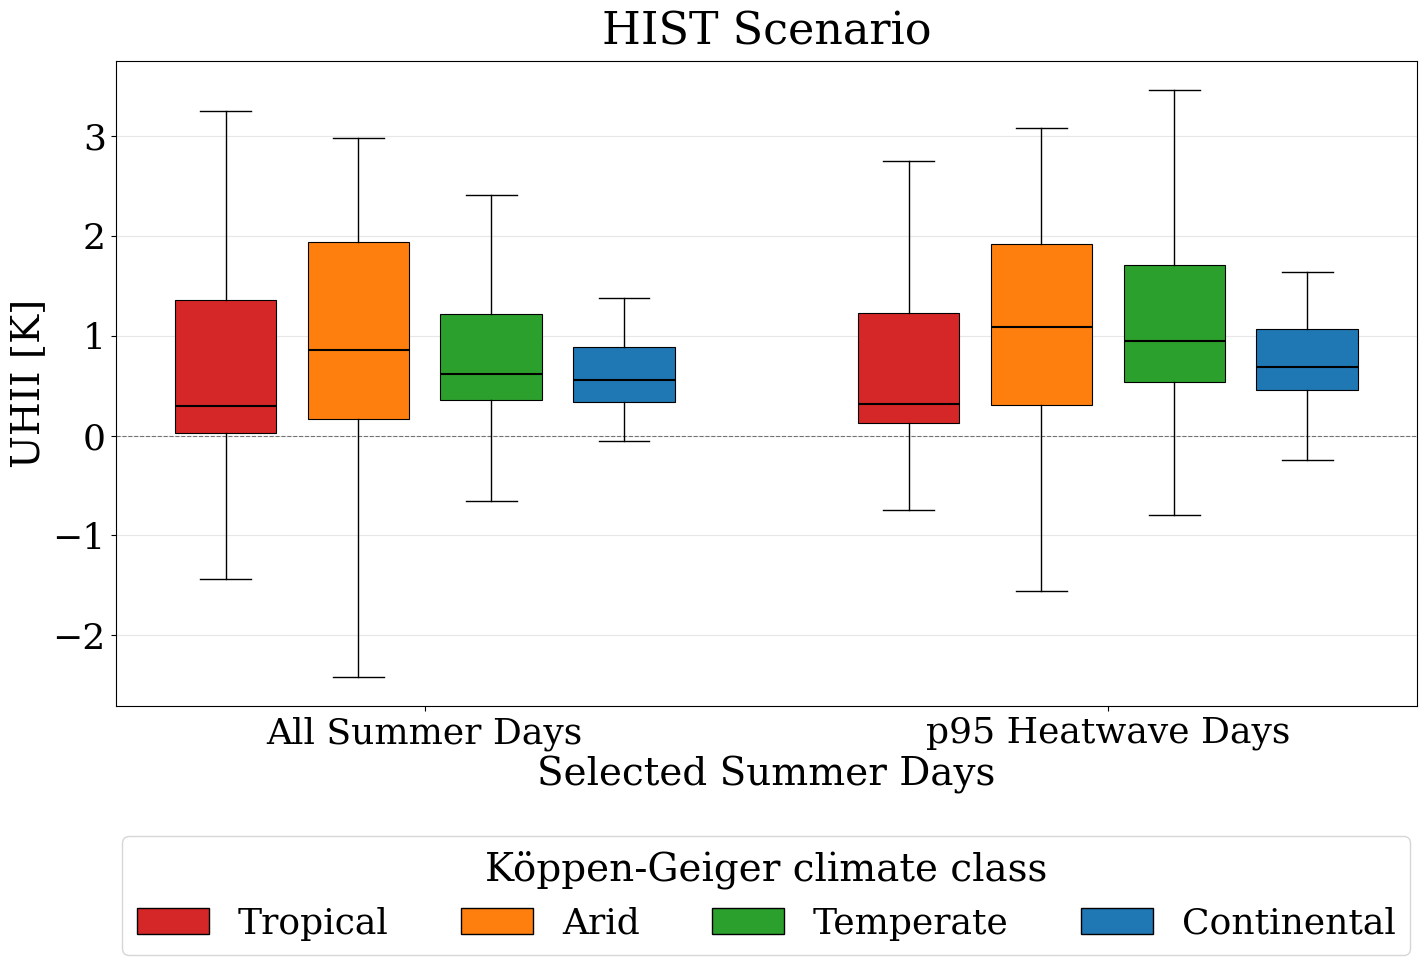

In [19]:
plot_uhii_boxplot_by_heatwave_and_climate(summer_climate_metrics_HIST, print_outliers=False, show_outlier=False,
                                          title="HIST Scenario",
                                          ylabel="UHII [K]",
                                          xlabel="Selected Summer Days",
                                          save_path=save_figures_to,
                                          output_name="Boxplot_UHII_HIST_HW_Condition_KG.pdf")

# Plot global map of A(UHII) in HIST 

Data range: -1.1393 to 2.4581
Colorbar range (IQR): -0.6760 to 1.1194
Outliers: 10 cities
Number of positive values: 156
Number of negative values: 53
Number of zero values: 0
Processing Köppen-Geiger land background (main groups)...


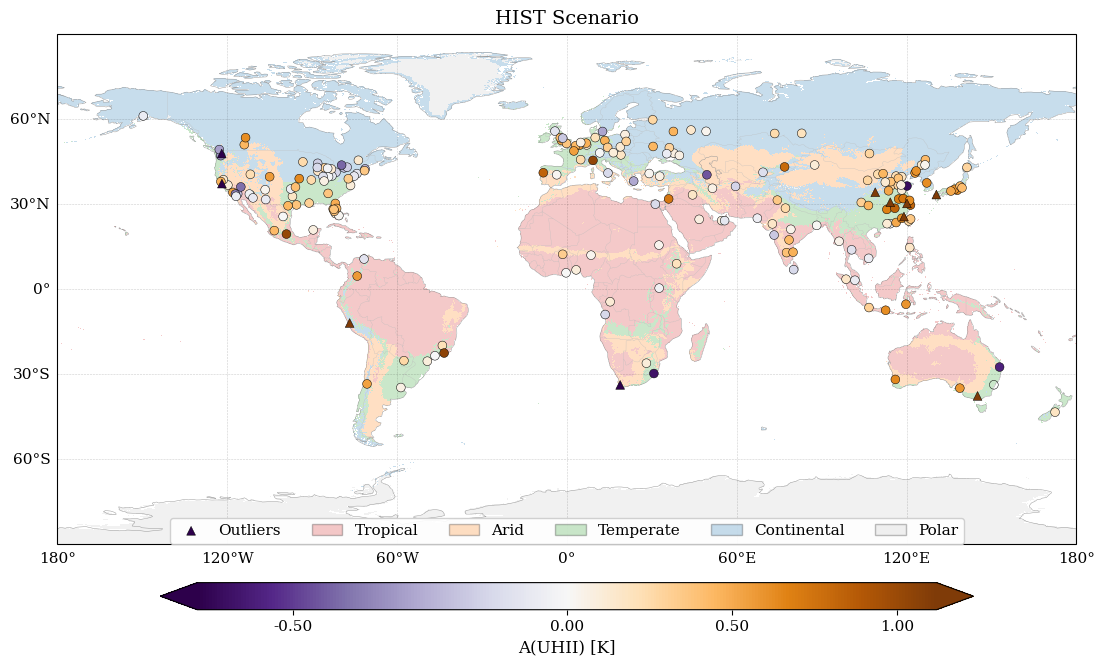

In [30]:
plot_temp_diff_with_cc(amplification_HIST, cc_kogei,
                       variable="amplification_UHII_summer", 
                       cmap="PuOr_r", 
                       title="HIST Scenario",
                       xlabel="A(UHII)", 
                       save_path=save_figures_to, 
                       output_name="Global_Map_A(UHII)_HIST_with_CC.pdf")

# Plot boxplot of A(UHII) in HIST

SUMMARY STATISTICS
 A: n=    42    mean=  0.101    median=  0.039    std=  0.262    range=[ -0.409,   1.054]    IQR=[ -0.047,    0.164]
 B: n=    31    mean=  0.155    median=  0.108    std=  0.518    range=[ -0.832,   2.458]    IQR=[ -0.092,    0.286]
 C: n=    85    mean=  0.321    median=  0.374    std=  0.456    range=[ -1.139,   1.586]    IQR=[  0.102,    0.549]
 D: n=    51    mean=  0.232    median=  0.190    std=  0.358    range=[ -0.425,   1.920]    IQR=[  0.012,    0.429]


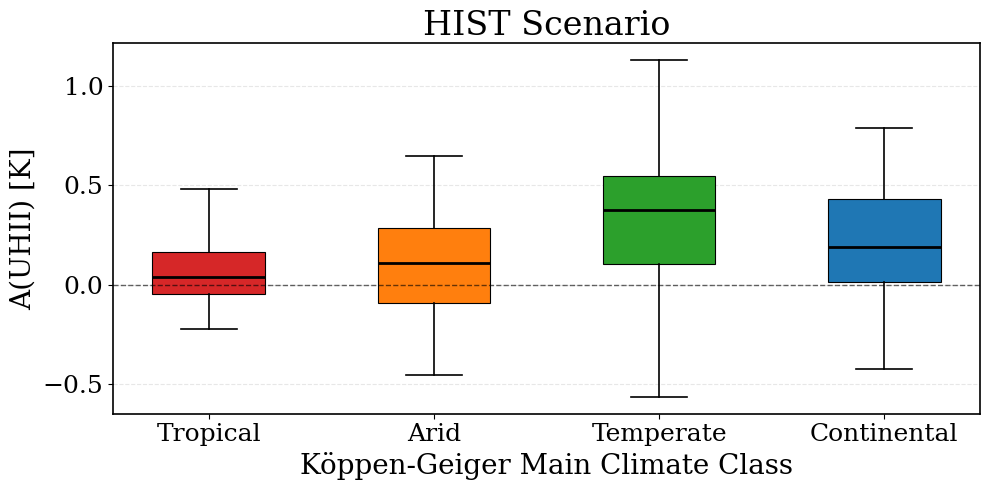

In [28]:
plot_uhii_boxplot_and_climate(amplification_HIST, variable="amplification_UHII_summer", groupby="kg_main",
                              show_outlier=False, print_outliers=False,
                              title="HIST Scenario",
                              ylabel="A(UHII) [K]",
                              save_path=save_figures_to,
                              output_name="Boxplot_A(UHII)_HIST.pdf")

# Plot global map of $\Delta$UHII 

In [24]:
all_values = np.concatenate([summer_climate_metrics_HIST_CONT_diff["UHII_summer_HIST_CONT_abs_diff"].values,
                             summer_climate_metrics_HIST_T2K_diff["UHII_summer_T2K_HIST_abs_diff"].values])

q1=np.nanpercentile(all_values, 25)
q3=np.nanpercentile(all_values, 75)
iqr = q3 - q1
shared_min = q1 - 1.5 * iqr
shared_max = q3 + 1.5 * iqr

In [25]:
all_values_p95 = np.concatenate([summer_climate_metrics_HIST_CONT_diff["UHII_summer_p95_HIST_CONT_abs_diff"].values,
                                 summer_climate_metrics_HIST_T2K_diff["UHII_summer_p95_T2K_HIST_abs_diff"].values])

q1_p95=np.nanpercentile(all_values_p95, 25)
q3_p95=np.nanpercentile(all_values_p95, 75)
iqr_p95 = q3_p95 - q1_p95
shared_min_p95 = q1_p95 - 1.5 * iqr_p95
shared_max_p95 = q3_p95 + 1.5 * iqr_p95

## HIST - CONT

Data range: -0.3765 to 0.3656
Colorbar range (IQR): -0.0758 to 0.0731
Outliers: 17 cities
Number of positive values: 100
Number of negative values: 110
Number of zero values: 0
Processing Köppen-Geiger land background (main groups)...


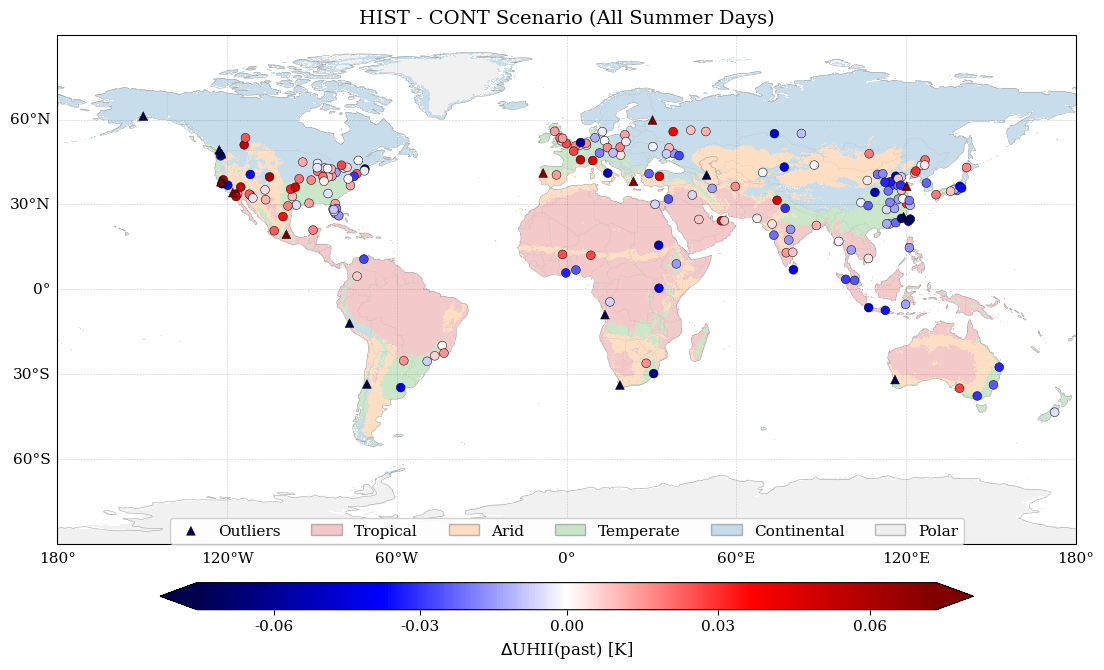

In [27]:
plot_temp_diff_with_cc(summer_climate_metrics_HIST_CONT_diff, cc_kogei,
                       variable="UHII_summer_HIST_CONT_abs_diff",
                       vmin=shared_min, vmax=shared_max,
                       title="HIST - CONT Scenario (All Summer Days)",
                       xlabel="$\\Delta$UHII(past)",
                       colorbar_tick_step=0.03,
                       save_path=save_figures_to,
                       output_name="Global_Map_Delta_UHII_HIST_CONT_with_cc.pdf")

Data range: -0.7582 to 0.4185
Colorbar range (IQR): -0.1847 to 0.2094
Outliers: 15 cities
Number of positive values: 112
Number of negative values: 97
Number of zero values: 0
Processing Köppen-Geiger land background (main groups)...


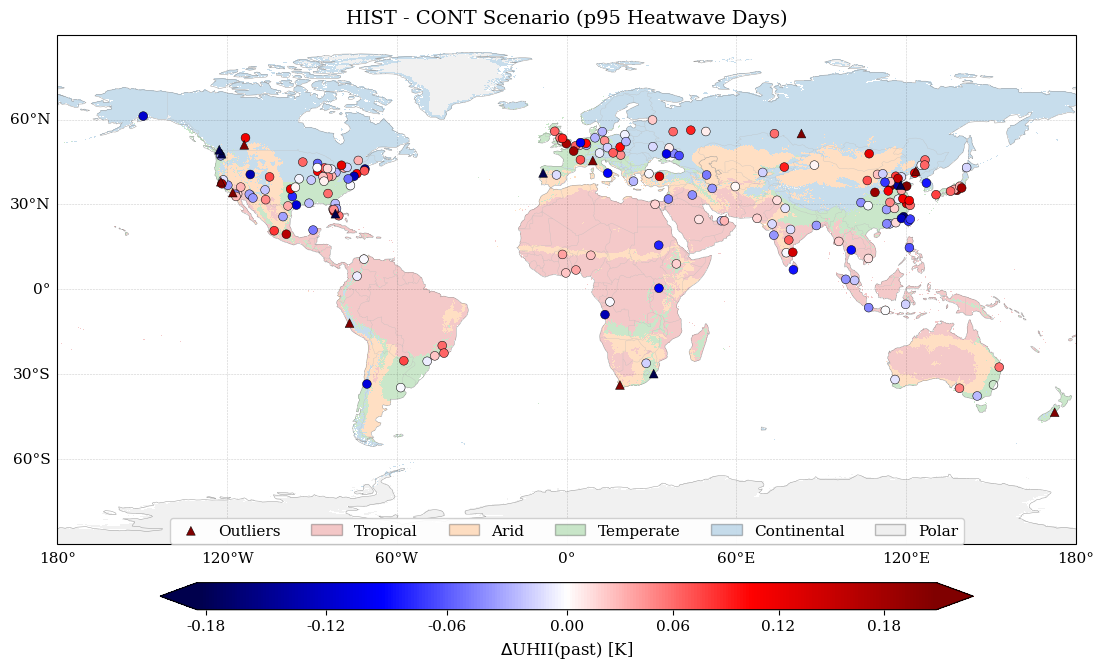

In [29]:
plot_temp_diff_with_cc(summer_climate_metrics_HIST_CONT_diff, cc_kogei,
                       variable="UHII_summer_p95_HIST_CONT_abs_diff",
                       vmin=shared_min_p95, vmax=shared_max_p95,
                       title="HIST - CONT Scenario (p95 Heatwave Days)",
                       xlabel="$\\Delta$UHII(past)",
                       colorbar_tick_step=0.06,
                       save_path=save_figures_to,
                       output_name="Global_Map_Delta_UHII_HIST_CONT_p95_with_cc.pdf")

## T2K - HIST

Data range: -0.3926 to 0.1825
Colorbar range (IQR): -0.0758 to 0.0731
Outliers: 21 cities
Number of positive values: 114
Number of negative values: 96
Number of zero values: 0
Processing Köppen-Geiger land background (main groups)...


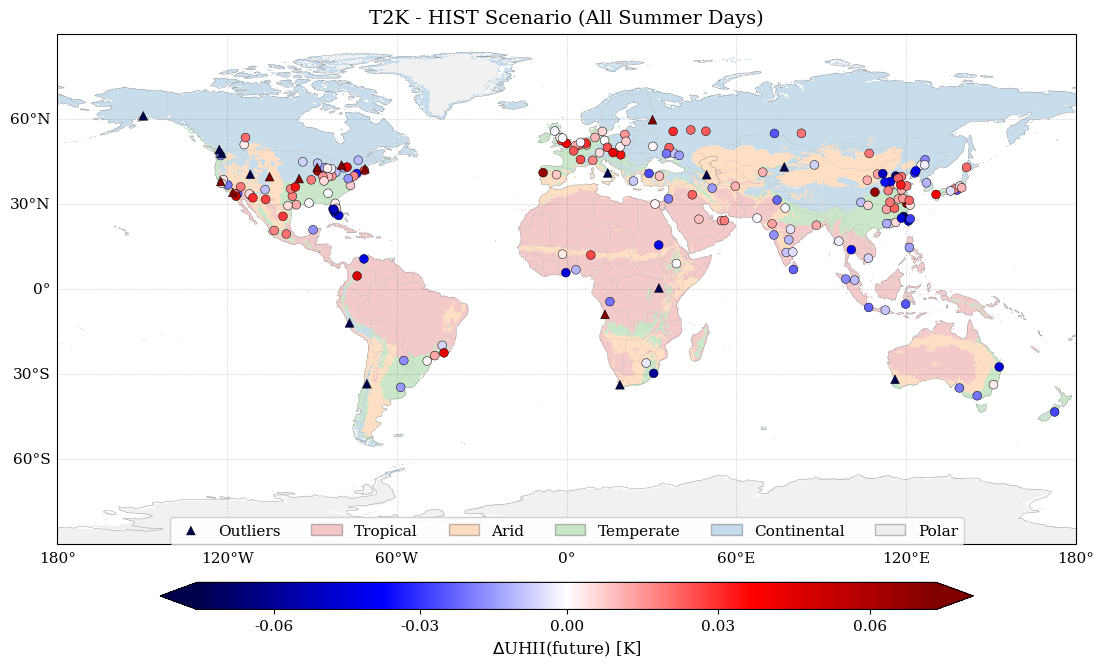

In [30]:
plot_temp_diff_with_cc(summer_climate_metrics_HIST_T2K_diff, cc_kogei,
                       variable="UHII_summer_T2K_HIST_abs_diff",
                       vmin=shared_min, vmax=shared_max,
                       title="T2K - HIST Scenario (All Summer Days)",
                       xlabel="$\\Delta$UHII(future)",
                       colorbar_tick_step=0.03,
                       save_path=save_figures_to,
                       output_name="Global_Map_Delta_UHII_T2K_HIST_with_cc.pdf")

Data range: -1.0928 to 0.4899
Colorbar range (IQR): -0.1847 to 0.2094
Outliers: 23 cities
Number of positive values: 109
Number of negative values: 100
Number of zero values: 0
Processing Köppen-Geiger land background (main groups)...


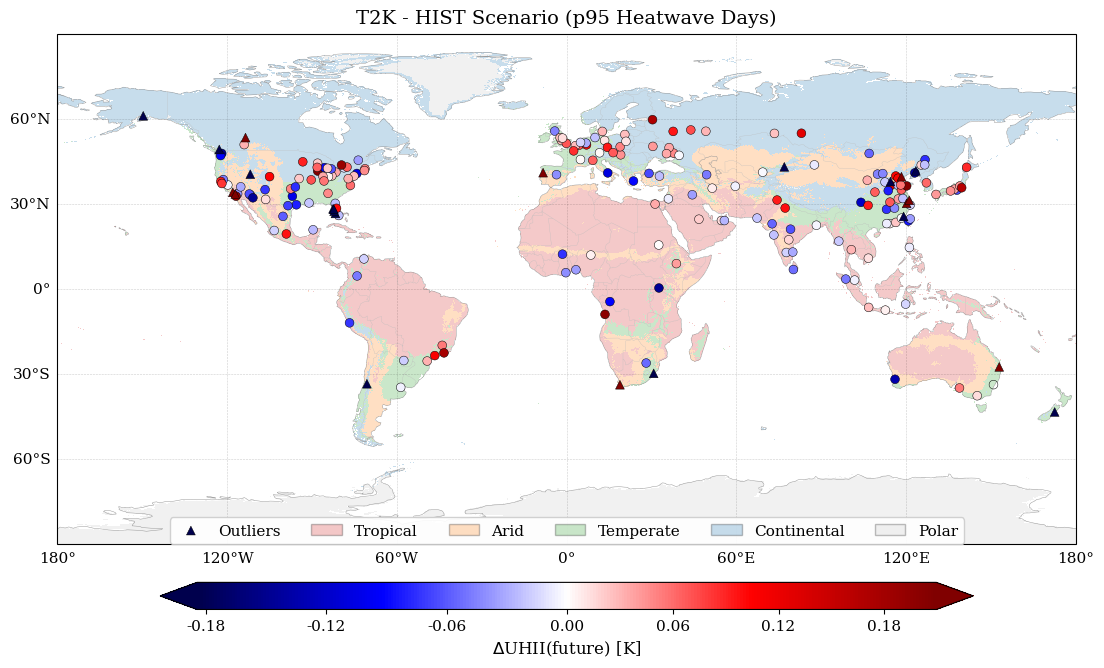

In [31]:
plot_temp_diff_with_cc(summer_climate_metrics_HIST_T2K_diff, cc_kogei,
                       variable="UHII_summer_p95_T2K_HIST_abs_diff",
                       vmin=shared_min_p95, vmax=shared_max_p95,
                       title="T2K - HIST Scenario (p95 Heatwave Days)",
                       xlabel="$\\Delta$UHII(future)",
                       colorbar_tick_step=0.06,
                       save_path=save_figures_to,
                       output_name="Global_Map_Delta_UHII_T2K_HIST_p95_with_cc.pdf")

# Plot boxplot of $\Delta$UHII 

## HIST - CONT

SUMMARY STATISTICS

 All Summer Days:
 A: n=    42    mean= -0.004    median= -0.004    std=  0.024    range=[ -0.049,   0.052]    IQR=[ -0.020,    0.012]
 B: n=    31    mean= -0.013    median= -0.004    std=  0.068    range=[ -0.184,   0.139]    IQR=[ -0.038,    0.018]
 C: n=    86    mean= -0.002    median= -0.003    std=  0.070    range=[ -0.376,   0.366]    IQR=[ -0.020,    0.016]
 D: n=    51    mean= -0.002    median=  0.003    std=  0.036    range=[ -0.139,   0.076]    IQR=[ -0.012,    0.017]

 p95 Heatwave Days:
 A: n=    42    mean= -0.003    median= -0.002    std=  0.048    range=[ -0.097,   0.139]    IQR=[ -0.038,    0.025]
 B: n=    31    mean=  0.036    median= -0.002    std=  0.106    range=[ -0.130,   0.301]    IQR=[ -0.024,    0.077]
 C: n=    85    mean=  0.010    median=  0.019    std=  0.151    range=[ -0.758,   0.418]    IQR=[ -0.029,    0.076]
 D: n=    51    mean=  0.026    median=  0.022    std=  0.098    range=[ -0.197,   0.296]    IQR=[ -0.016,    0.068]


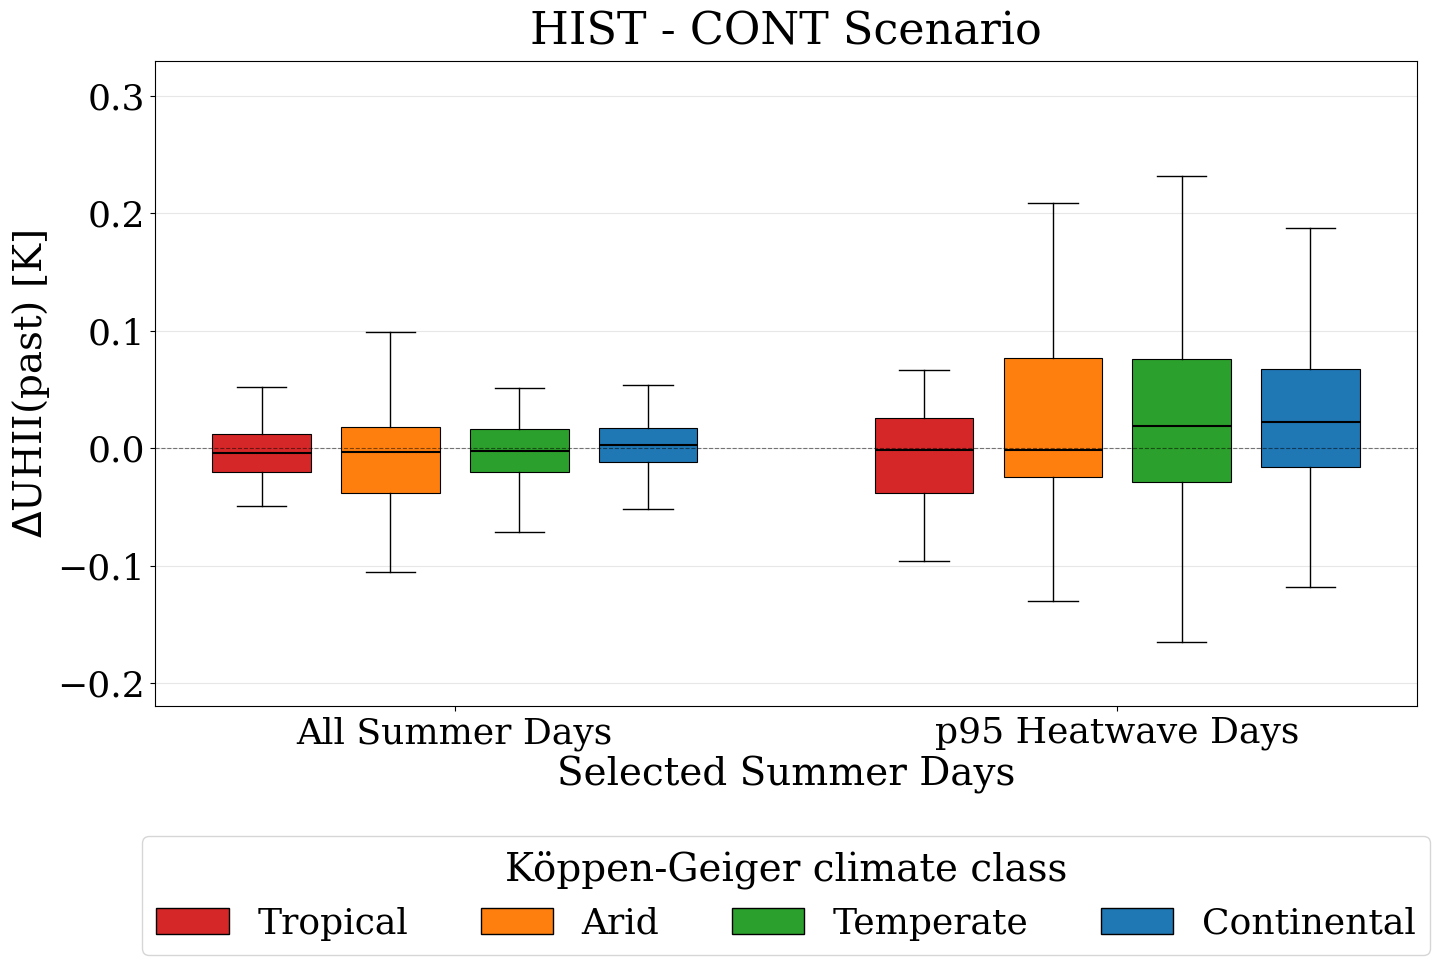

In [18]:
plot_uhii_boxplot_by_heatwave_and_climate(summer_climate_metrics_HIST_CONT_diff, print_outliers=False, show_outlier=False,
                                          variable="UHII_summer",
                                          variable_suffix="HIST_CONT_abs_diff",
                                          vmax=0.33,
                                          vmin=-0.22,
                                          title="HIST - CONT Scenario",
                                          ylabel="$\\Delta$UHII(past) [K]",
                                          xlabel="Selected Summer Days",
                                          save_path=save_figures_to,
                                          output_name="Boxplot_Delta_UHII_HIST-CONT_HW_Condition_KG.pdf")

## T2K - HIST 

SUMMARY STATISTICS

 All Summer Days:
 A: n=    42    mean= -0.009    median= -0.009    std=  0.023    range=[ -0.079,   0.045]    IQR=[ -0.022,    0.008]
 B: n=    31    mean= -0.014    median= -0.001    std=  0.060    range=[ -0.185,   0.124]    IQR=[ -0.038,    0.013]
 C: n=    86    mean= -0.003    median=  0.005    std=  0.053    range=[ -0.393,   0.106]    IQR=[ -0.015,    0.018]
 D: n=    51    mean=  0.013    median=  0.004    std=  0.060    range=[ -0.160,   0.183]    IQR=[ -0.009,    0.024]

 p95 Heatwave Days:
 A: n=    42    mean= -0.013    median= -0.019    std=  0.051    range=[ -0.146,   0.178]    IQR=[ -0.038,    0.011]
 B: n=    31    mean=  0.021    median= -0.018    std=  0.147    range=[ -0.308,   0.455]    IQR=[ -0.060,    0.104]
 C: n=    85    mean= -0.018    median=  0.006    std=  0.175    range=[ -1.093,   0.490]    IQR=[ -0.059,    0.057]
 D: n=    51    mean=  0.021    median=  0.036    std=  0.122    range=[ -0.494,   0.246]    IQR=[  0.001,    0.066]


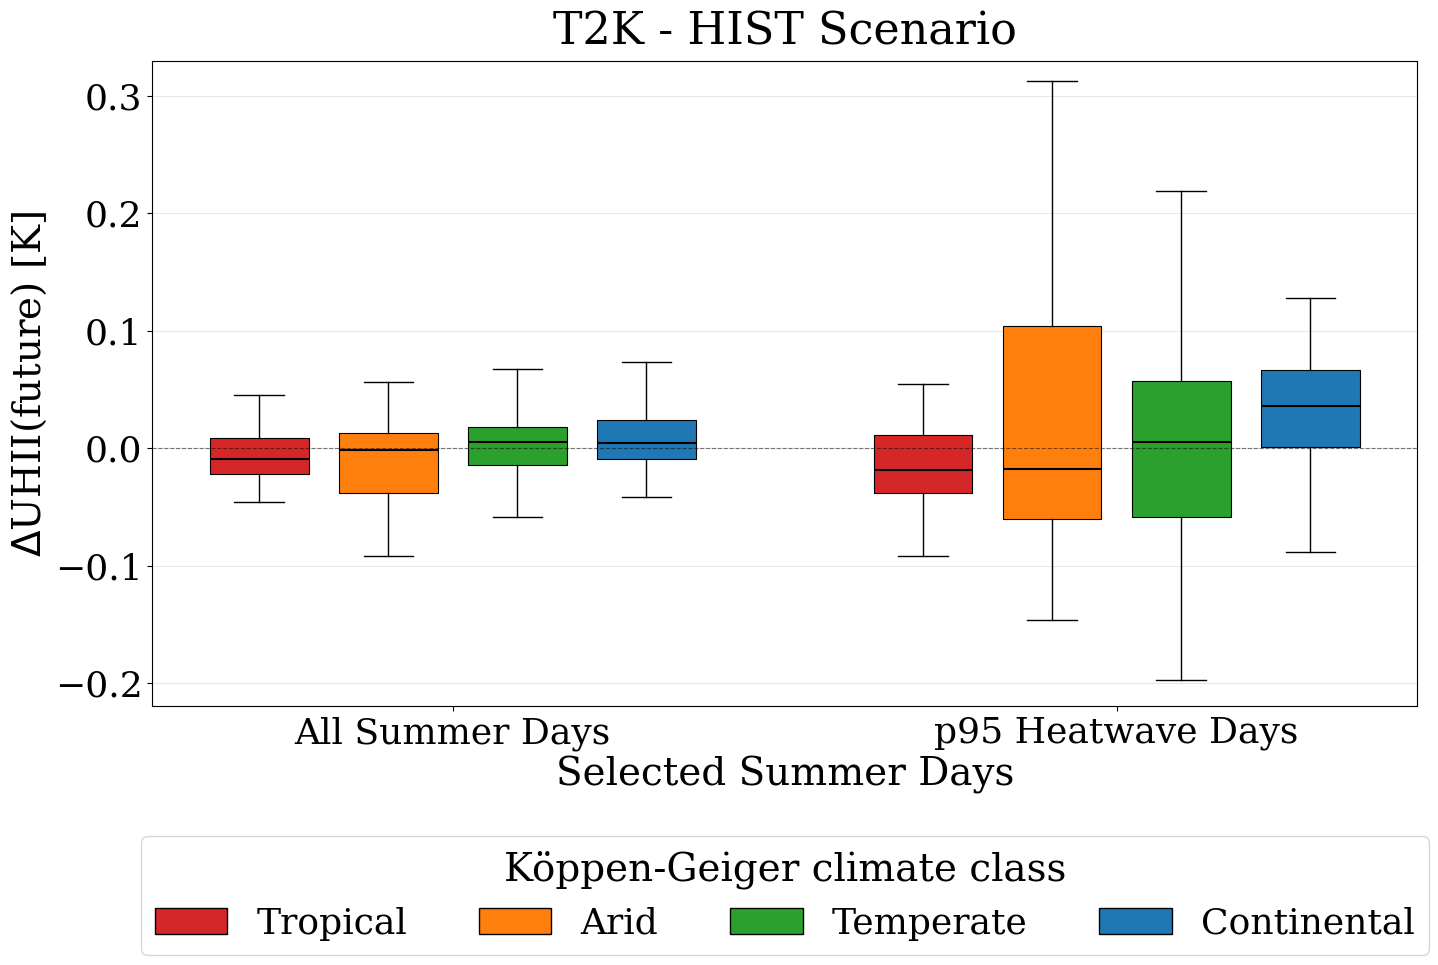

In [22]:
plot_uhii_boxplot_by_heatwave_and_climate(summer_climate_metrics_HIST_T2K_diff, print_outliers=False, show_outlier=False,
                                          variable="UHII_summer",
                                          variable_suffix="T2K_HIST_abs_diff",
                                          vmax=0.33,
                                          vmin=-0.22,
                                          title="T2K - HIST Scenario",
                                          ylabel="$\\Delta$UHII(future) [K]",
                                          xlabel="Selected Summer Days",
                                          save_path=save_figures_to,
                                          output_name="Boxplot_Delta_UHII_T2K-HIST_HW_Condition_KG.pdf")

# Plot global map of A($\Delta$UHII) 

In [27]:
all_values = np.concatenate([amplification_HIST_CONT_diff["amplification_UHII_summer"].values,
                             amplification_T2K_HIST_diff["amplification_UHII_summer"].values])

q1=np.nanpercentile(all_values, 25)
q3=np.nanpercentile(all_values, 75)
iqr = q3 - q1
shared_min = q1 - 1.5 * iqr
shared_max = q3 + 1.5 * iqr

## HIST - CONT

Data range: -0.7983 to 0.4862
Colorbar range (IQR): -0.1698 to 0.1915
Outliers: 17 cities
Number of positive values: 121
Number of negative values: 88
Number of zero values: 0
Processing Köppen-Geiger land background (main groups)...


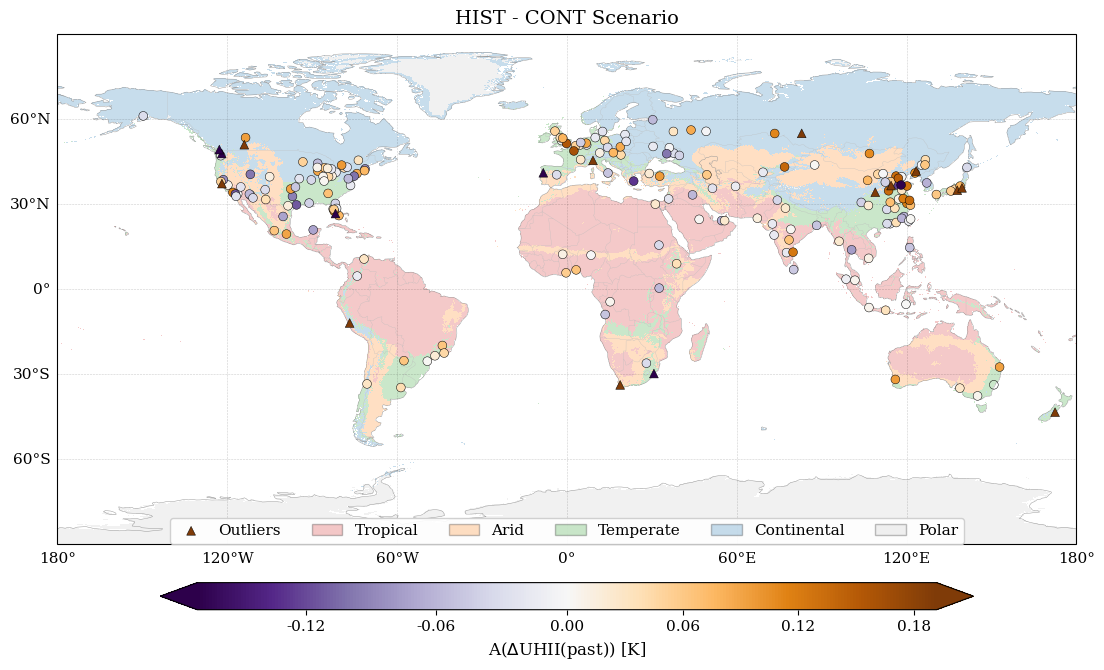

In [26]:
plot_temp_diff_with_cc(amplification_HIST_CONT_diff, cc_kogei,
                       variable="amplification_UHII_summer", 
                       cmap="PuOr_r",
                       vmin=shared_min, vmax=shared_max,
                       title="HIST - CONT Scenario",
                       xlabel="A($\\Delta$UHII(past))",
                       colorbar_tick_step=0.06,
                       save_path=save_figures_to,
                       output_name="Global_Map_A(Delta_UHII)_HIST_CONT_with_cc.pdf")

## T2K - HIST

Data range: -0.7288 to 0.4368
Colorbar range (IQR): -0.1698 to 0.1915
Outliers: 19 cities
Number of positive values: 113
Number of negative values: 96
Number of zero values: 0
Processing Köppen-Geiger land background (main groups)...


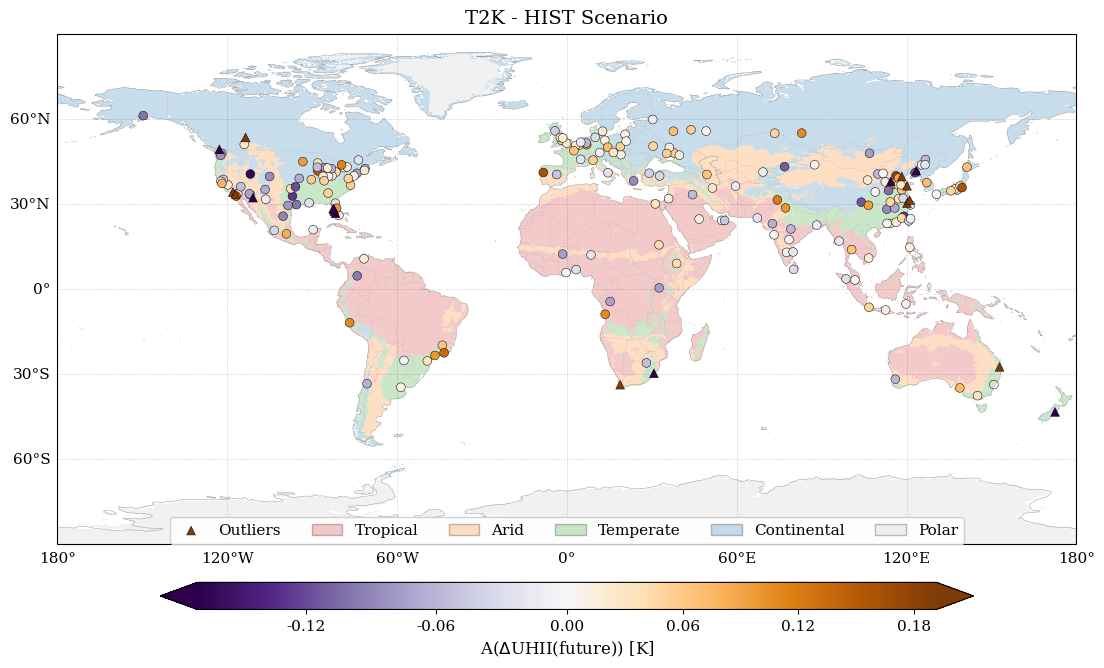

In [25]:
plot_temp_diff_with_cc(amplification_T2K_HIST_diff, cc_kogei,
                       variable="amplification_UHII_summer", 
                       cmap="PuOr_r",
                       vmin=shared_min, vmax=shared_max,
                       title="T2K - HIST Scenario",
                       xlabel="A($\\Delta$UHII(future))",
                       colorbar_tick_step=0.06,
                       save_path=save_figures_to,
                       output_name="Global_Map_A(Delta_UHII)_T2K_HIST_with_cc.pdf")

# Plot boxplot of A($\Delta$UHII) 

## HIST - CONT

SUMMARY STATISTICS
 A: n=    42    mean=  0.000    median=  0.001    std=  0.044    range=[ -0.076,   0.123]    IQR=[ -0.024,    0.023]
 B: n=    31    mean=  0.049    median=  0.006    std=  0.137    range=[ -0.130,   0.486]    IQR=[ -0.032,    0.096]
 C: n=    85    mean=  0.013    median=  0.026    std=  0.141    range=[ -0.798,   0.395]    IQR=[ -0.031,    0.070]
 D: n=    51    mean=  0.029    median=  0.013    std=  0.090    range=[ -0.167,   0.291]    IQR=[ -0.022,    0.076]


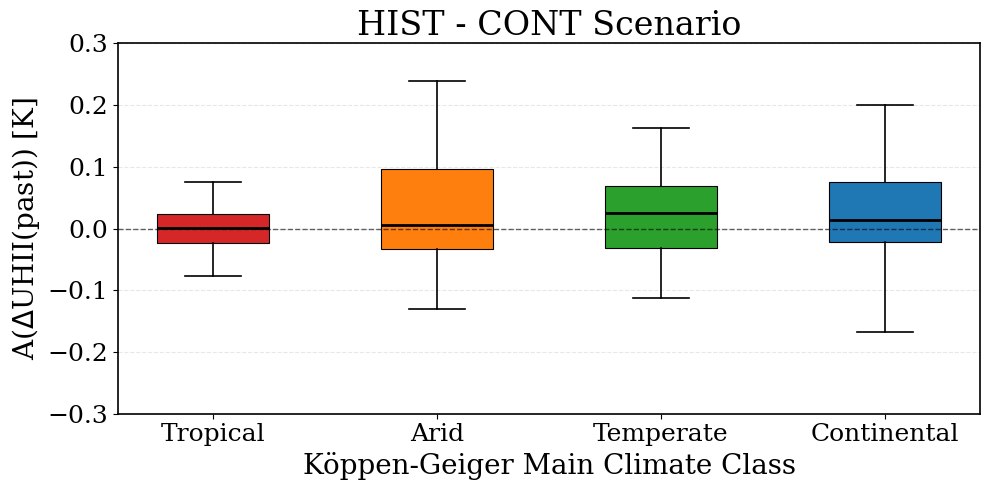

In [23]:
plot_uhii_boxplot_and_climate(amplification_HIST_CONT_diff,
                              show_outlier=False,
                              print_outliers=False,
                              vmax=0.3, vmin=-0.3,
                              title="HIST - CONT Scenario",
                              ylabel="A($\\Delta$UHII(past)) [K]",
                              save_path=save_figures_to,
                              output_name="Boxplot_A(Delta_UHII)_HIST-CONT.pdf")

## T2K - HIST

SUMMARY STATISTICS
 A: n=    42    mean= -0.005    median= -0.009    std=  0.045    range=[ -0.076,   0.135]    IQR=[ -0.030,    0.017]
 B: n=    31    mean=  0.035    median=  0.007    std=  0.138    range=[ -0.268,   0.424]    IQR=[ -0.049,    0.108]
 C: n=    85    mean= -0.015    median=  0.009    std=  0.141    range=[ -0.729,   0.437]    IQR=[ -0.068,    0.051]
 D: n=    51    mean=  0.009    median=  0.017    std=  0.097    range=[ -0.456,   0.232]    IQR=[ -0.024,    0.054]


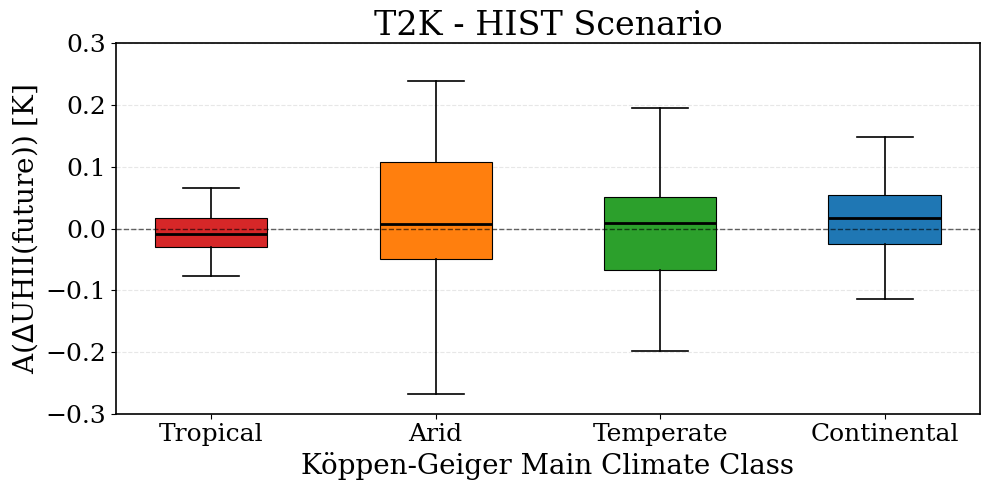

In [24]:
plot_uhii_boxplot_and_climate(amplification_T2K_HIST_diff,
                              show_outlier=False,
                              print_outliers=False,
                              vmax=0.3, vmin=-0.3,
                              title="T2K - HIST Scenario",
                              ylabel="A($\\Delta$UHII(future)) [K]",
                              save_path=save_figures_to,
                              output_name="Boxplot_A(Delta_UHII)_T2K-HIST.pdf")